# Activity inference in video – Reproduction des algorithmes

Ce notebook implémente, sous forme modulaire et commentée, une partie des algorithmes décrits dans le rapport *Activity inference in video* (Aurélien Louis, 2004), relatifs à la reconnaissance de forme.
On implémente ici le shape context, avec une distance plus simple que celle du rapport (pas de transformation TPS), on fait un spectral embedding et on essaye de séparer les classes via un K Means.

## 1. Préliminaires et dépendances

In [1]:
import numpy as np
import scipy as sp
import scipy.spatial
import scipy.optimize
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.sparse.linalg import eigsh

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from sklearn.datasets import fetch_openml

## 2. Extraction des contours et points de contrôle (Section 2.2.1)

In [2]:
def extract_edges(image, low=100, high=200):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Canny(gray, low, high)


def sample_contour_points(edges, n_points=100):
    ys, xs = np.where(edges > 0)
    if len(xs) == 0:
        return np.empty((0, 2))
    idx = np.linspace(0, len(xs) - 1, n_points).astype(int)
    return np.stack([xs[idx], ys[idx]], axis=1)

## 3. Shape Contexts (Sections 2.2.2–2.2.3)

In [3]:

def shape_context(points, n_r=5, n_theta=12):
    dists = sp.spatial.distance.cdist(points, points)
    mean_dist = dists.mean()
    dists /= mean_dist
    angles = np.arctan2(points[:, None, 1] - points[None, :, 1],
                        points[:, None, 0] - points[None, :, 0])

    r_bins = np.logspace(-1, 1, n_r)
    t_bins = np.linspace(-np.pi, np.pi, n_theta + 1)
    contexts = []

    for i in range(len(points)):
        hist = np.zeros((n_r, n_theta))
        for j in range(len(points)):
            if i == j:
                continue
            r = dists[i, j]
            t = angles[i, j]
            rb = np.searchsorted(r_bins, r) - 1
            tb = np.searchsorted(t_bins, t) - 1
            if 0 <= rb < n_r and 0 <= tb < n_theta:
                hist[rb, tb] += 1
        hist /= hist.sum() + 1e-8
        contexts.append(hist.flatten())
    return np.array(contexts)


def chi2_cost(h1, h2):
    return 0.5 * np.sum((h1 - h2)**2 / (h1 + h2 + 1e-8))


## 4. Appariement optimal – Algorithme hongrois (2.2.3)

In [4]:

def matching_cost(ctx1, ctx2):
    C = np.zeros((len(ctx1), len(ctx2)))
    for i in range(len(ctx1)):
        for j in range(len(ctx2)):
            C[i, j] = chi2_cost(ctx1[i], ctx2[j])
    return C


def hungarian_matching(C):
    r, c = sp.optimize.linear_sum_assignment(C)
    return list(zip(r, c))


## 5. Distance entre formes (Section 2.2.5)

In [5]:

def shape_distance(cost_matrix, matching):
    return np.mean([cost_matrix[i, j] for i, j in matching])


## 6. Embedding spectral (Sections 1.3.1–1.3.4)

In [6]:

def spectral_embedding(W, n_dims=5):
    D = np.diag(W.sum(axis=1))
    L = D - W
    vals, vecs = eigsh(L, k=n_dims + 1, M=D, which='SM')
    return vecs[:, 1:n_dims+1]


## 7. Clustering final des activités

In [7]:

def cluster_embedding(X, K):
    return KMeans(n_clusters=K).fit_predict(X)


## Tests du notebook
Tout d'abord, charger MNIST

In [8]:
def load_mnist(n_train=300, n_test=100, random_state=0):
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X = mnist.data.reshape(-1, 28, 28).astype(np.uint8)
    y = mnist.target.astype(int)

    return X, y

X, y = load_mnist()

np.int64(0)

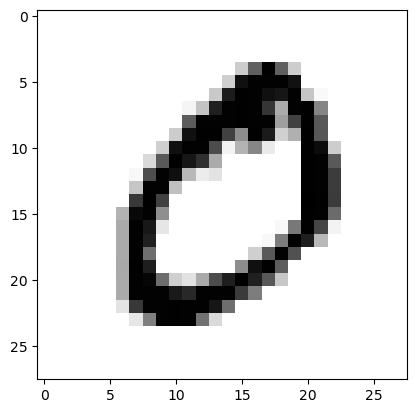

In [9]:
plt.imshow(X[1].reshape(28, 28), cmap='gray_r')
y[1]

Détecter les contours et déterminer les points de contrôle

In [10]:
def image_to_points(img, n_points=20):
    edges = cv2.Canny(img, 80, 160)
    ys, xs = np.where(edges > 0)

    if len(xs) < n_points:
        return None  # rejet image trop pauvre

    idx = np.linspace(0, len(xs) - 1, n_points).astype(int)
    points = np.stack([xs[idx], ys[idx]], axis=1)
    return points


In [11]:
def build_shapes(X):
    shapes = []
    for img in tqdm(X):
        pts = image_to_points(img)
        shapes.append(pts)
    return shapes

shapes = build_shapes(X)

100%|██████████| 70000/70000 [00:04<00:00, 16466.19it/s]


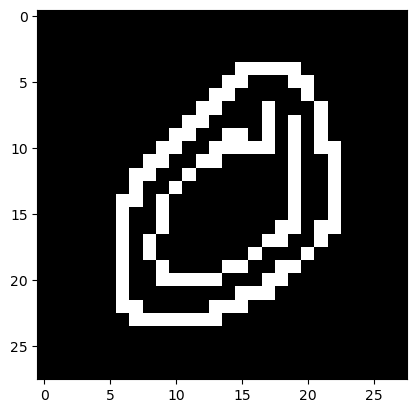

In [12]:
plt.imshow(cv2.Canny(X[1],80,160), cmap='gray')
plt.show()

In [30]:
img = image_to_points(X[1],50)

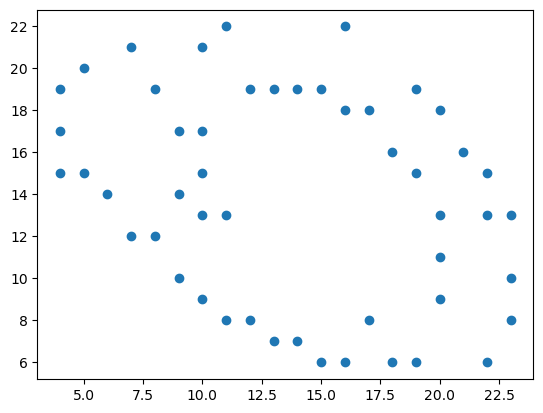

In [14]:
plt.scatter(img[:,1], img[:,0])
plt.show()

Calcul du contexte

In [31]:
def compute_shape_contexts(shapes):
    contexts = []
    for pts in tqdm(shapes):
        if pts is None:
            contexts.append(None)
        else:
            contexts.append(shape_context(pts))
    return contexts


ctx = compute_shape_contexts(shapes[:500])

100%|██████████| 500/500 [00:00<00:00, 552.16it/s]


Calcul un peu long tout de même...

In [32]:
def shape_context_distance(ctx1, ctx2):
    if ctx1 is None or ctx2 is None:
        return np.inf

    C = matching_cost(ctx1, ctx2)
    matching = hungarian_matching(C)
    return shape_distance(C, matching)

In [33]:
def compute_distance_matrix(train_ctx, test_ctx):
    D = np.zeros((len(test_ctx), len(train_ctx)))

    for i, ctx_test in enumerate(tqdm(test_ctx)):
        for j, ctx_train in enumerate(train_ctx):
            D[i, j] = shape_context_distance(ctx_test, ctx_train)

    return D


D = compute_distance_matrix(ctx, ctx)


100%|██████████| 500/500 [10:30<00:00,  1.26s/it]


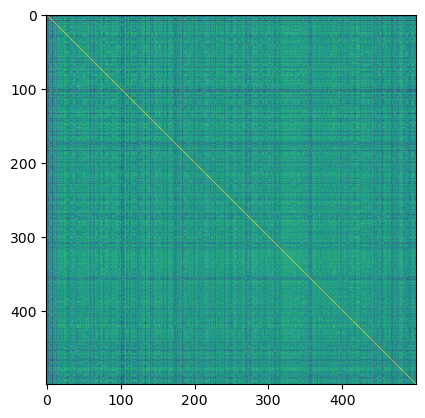

In [34]:
plt.imshow(1-D)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(20, 60))

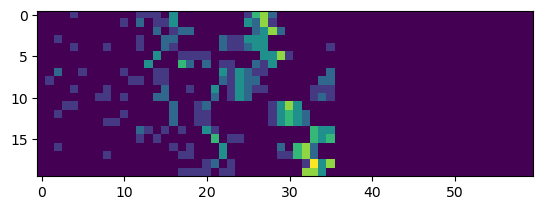

In [35]:
plt.imshow(ctx[1])
ctx[1]

In [36]:
eigen=spectral_embedding(1-D,4)
groups=cluster_embedding(eigen, 10)

C:\Users\LOUISA\AppData\Local\anaconda3\envs\Toolbox\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


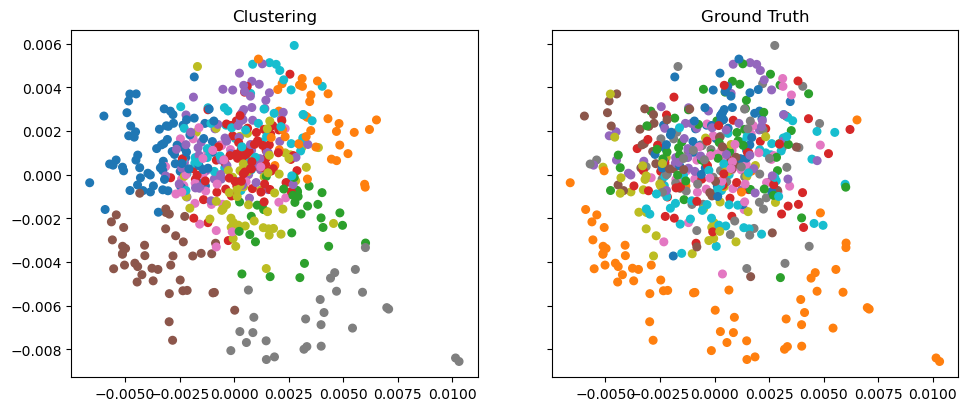

In [38]:
a = eigen[:,0]
b = eigen[:,1]

import matplotlib.colors as mcolors

cmap = plt.get_cmap("tab10")
norm = mcolors.BoundaryNorm(boundaries=range(11), ncolors=10)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True,constrained_layout=True)

axes[0].scatter(
    a, b,
    c=groups,
    cmap=cmap,
    norm=norm,
    s=30
)
axes[0].set_title("Clustering")

axes[1].scatter(
    a, b,
    c=y[:500],
    cmap=cmap,
    norm=norm,
    s=30
)
axes[1].set_title("Ground Truth")


for ax in axes:
    ax.set_aspect("equal", adjustable="box")

plt.show()


In [41]:
a

array([-1.58630304e-03,  3.00520524e-04,  8.51234952e-04, -5.90825380e-03,
        1.25954917e-03,  1.05832863e-04,  4.41942795e-03, -8.14125451e-04,
        1.01479086e-02, -4.49525827e-03,  7.88626921e-04, -4.90888279e-03,
        2.34269404e-03, -1.27738100e-03,  5.42637581e-03, -1.65858786e-04,
       -1.46759706e-04, -2.67634877e-03, -1.19795628e-03, -1.57625196e-03,
        2.09684255e-03, -9.91735061e-04,  7.63679356e-05, -5.05838248e-03,
        1.69609504e-03, -1.50455929e-03,  1.22913754e-03,  8.52261287e-04,
        3.51270463e-03, -1.67755302e-03,  3.27672157e-03, -5.11238699e-03,
        1.44779386e-03, -2.30448676e-03, -1.89262356e-03, -4.42154282e-03,
        3.43813901e-03, -8.72805488e-04,  2.20122525e-03,  8.00962337e-04,
        5.65725443e-04, -2.47811533e-03,  1.47448067e-03, -1.50821849e-03,
        4.02970803e-03,  3.14060014e-04, -1.31561637e-04, -3.37629250e-03,
        4.96832054e-03,  6.54030237e-04,  7.05103329e-04,  2.16839625e-03,
        3.10540510e-03, -

In [40]:

from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

cm = confusion_matrix(y[:500], groups)

row_ind, col_ind = linear_sum_assignment(-cm)

acc = cm[row_ind, col_ind].sum() / cm.sum()
print(acc)   # 1.0



0.384
